# 05A.1 — Single Well FEniCSx 1D Elasticity Foundations

Este notebook é o primeiro uso real do **FEniCSx** no projeto.

Ele vem depois do notebook `05A`, que resolveu elasticidade 1D de forma didática com NumPy.

Agora vamos resolver uma PDE elástica simples usando FEM real:

```text
-d/dx( E(x) du/dx ) = f(x)
```

Onde:

- `u(x)` é o deslocamento;
- `E(x)` vem do seu poço, preparado no notebook 04;
- `f(x)` é uma carga distribuída didática;
- a base da zona é fixa.

## Entrada

```text
data/physics_ready/parquet/single_well_fenics_ready/
```

## Saída

```text
data/simulation/parquet/single_well_fenicsx_elasticity_1d/
```

## Objetivo

Aprender a ponte:

```text
petrofísica
↓
campos físicos
↓
coeficientes da PDE
↓
FEniCSx / FEM
↓
deslocamento, deformação e tensão
```

# STEP 0 — Environment Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List, Optional
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import dolfinx
import ufl
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_PHYSICS_READY_DIR = Path("../data/physics_ready/parquet/single_well_fenics_ready")
DATA_SIMULATION_DIR = Path("../data/simulation/parquet/single_well_fenicsx_elasticity_1d")
REPORT_DIR = Path("../reports/single_well_fenicsx_elasticity_1d")

DATA_SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PHYSICS_READY_PARQUET_FILE: Optional[str] = None

# Carga distribuída didática.
BODY_FORCE = PETSc.ScalarType(-1.0e3)

print("FEniCSx OK")
print("dolfinx version:", dolfinx.__version__)
print(f"DATA_PHYSICS_READY_DIR = {DATA_PHYSICS_READY_DIR.resolve()}")
print(f"DATA_SIMULATION_DIR    = {DATA_SIMULATION_DIR.resolve()}")

FEniCSx OK
dolfinx version: 0.10.0.post2
DATA_PHYSICS_READY_DIR = /root/shared/data/physics_ready/parquet/single_well_fenics_ready
DATA_SIMULATION_DIR    = /root/shared/data/simulation/parquet/single_well_fenicsx_elasticity_1d


## Interpretação

Se esta célula rodou, seu ambiente FEniCSx está funcionando.

Agora vamos usar o FEniCSx para resolver uma PDE real.

# STEP 1 — Load Physics-Ready Parquet

In [2]:
def list_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet encontrado em: {data_dir.resolve()}")

    return files


def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print("Colunas duplicadas removidas mantendo a primeira ocorrência:")
        print(sorted(set(duplicated)))
    return df.loc[:, ~df.columns.duplicated()].copy()


physics_files = list_parquet_files(DATA_PHYSICS_READY_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in physics_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in physics_files],
}))

if PHYSICS_READY_PARQUET_FILE is None:
    selected_physics_path = physics_files[0]
else:
    selected_physics_path = DATA_PHYSICS_READY_DIR / PHYSICS_READY_PARQUET_FILE
    if not selected_physics_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_physics_path}")

df = pd.read_parquet(selected_physics_path)
df = make_unique_columns(df).sort_values("DEPTH").reset_index(drop=True)

if "WELL" in df.columns and df["WELL"].notna().any():
    WELL_NAME = str(df["WELL"].dropna().iloc[0])
else:
    WELL_NAME = selected_physics_path.stem.split("_fenics_ready")[0]

print(f"Arquivo selecionado: {selected_physics_path.name}")
print(f"Poço: {WELL_NAME}")
print(f"Shape: {df.shape}")
print(f"Depth min: {df['DEPTH'].min():,.3f}")
print(f"Depth max: {df['DEPTH'].max():,.3f}")

display(df.head())
display(df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_fenics_ready_2350m1_2400m0.parquet,2026-05-08 14:48:38.060850382


Arquivo selecionado: TFT-4_fenics_ready_2350m1_2400m0.parquet
Poço: TFT-4
Shape: (329, 16)
Depth min: 2,350.136
Depth max: 2,399.992


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
0,TFT-4,"2,350.136400","2,409.744322","4,564.744311","2,251.323467",0.334331,"12,256,840,817.437845","33,003,964,238.271610","32,786,153,018.229519","10,988,331.988865","5,424,147.760899",0.219376,"2,350.136400","2,399.992400",0.152000,True
1,TFT-4,"2,350.288400","2,409.362810","4,515.308239","2,218.423544",0.335592,"11,913,293,372.311029","32,545,065,165.444843","31,905,485,503.589760","10,872,226.132795","5,345,663.917131",0.251638,"2,350.136400","2,399.992400",0.152000,True
2,TFT-4,"2,350.440400","2,409.240171","4,464.553345","2,188.575913",0.336538,"11,605,362,566.700142","31,991,636,763.882751","31,103,994,897.294281","10,751,782.908020","5,274,144.908529",0.286587,"2,350.136400","2,399.992400",0.152000,True
3,TFT-4,"2,350.592400","2,409.144786","4,404.476525","2,157.580660",0.337273,"11,293,693,500.715904","31,261,745,368.586189","30,277,976,074.992485","10,609,289.794359","5,200,176.422041",0.318953,"2,350.136400","2,399.992400",0.152000,True
4,TFT-4,"2,350.744400","2,408.905709","4,337.697166","2,129.403432",0.337862,"11,010,394,982.113462","30,394,247,432.326649","29,503,347,628.122078","10,446,856.563887","5,131,202.094845",0.345972,"2,350.136400","2,399.992400",0.152000,True


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
324,TFT-4,"2,399.384400","2,425.259936","3,417.817492","1,865.594885",0.288048,"8,461,479,016.900890","16,970,268,536.367668","21,768,744,085.145435","8,269,377.572994","4,522,558.092900",0.596667,"2,350.136400","2,399.992400",0.152000,True
325,TFT-4,"2,399.536400","2,429.335634","3,428.954997","1,871.179920",0.288117,"8,530,592,123.557176","17,114,040,401.184122","21,941,982,585.864567","8,307,618.998616","4,545,282.536272",0.596311,"2,350.136400","2,399.992400",0.152000,True
326,TFT-4,"2,399.688400","2,434.430257","3,442.876878","1,878.114600",0.288204,"8,613,100,959.222910","17,293,755,232.205284","22,156,411,146.318531","8,355,420.780645","4,572,694.585376",0.595866,"2,350.136400","2,399.992400",0.152000,True
327,TFT-4,"2,399.840400","2,437.703252","3,460.776439","1,886.508270",0.288315,"8,701,405,940.235632","17,524,817,157.804939","22,397,248,085.329918","8,414,959.192313","4,602,911.181458",0.596467,"2,350.136400","2,399.992400",0.152000,True
328,TFT-4,"2,399.992400","2,439.323485","3,484.642521","1,897.699829",0.288398,"8,818,103,024.547861","17,832,899,725.233055","22,718,364,003.972057","8,490,158.764764","4,635,465.171205",0.597377,"2,350.136400","2,399.992400",0.152000,True


## Interpretação

Estamos lendo a camada `physics-ready`.

Aqui o poço já foi transformado em campos físicos contínuos e validados.

O campo mais importante deste notebook será:

```text
E_pa
```

Ele será usado como `E(x)` na PDE elástica.

# STEP 2 — Select Valid Points and Create Local Coordinate

Pontos válidos: 329
Comprimento da zona L = 49.856000 m


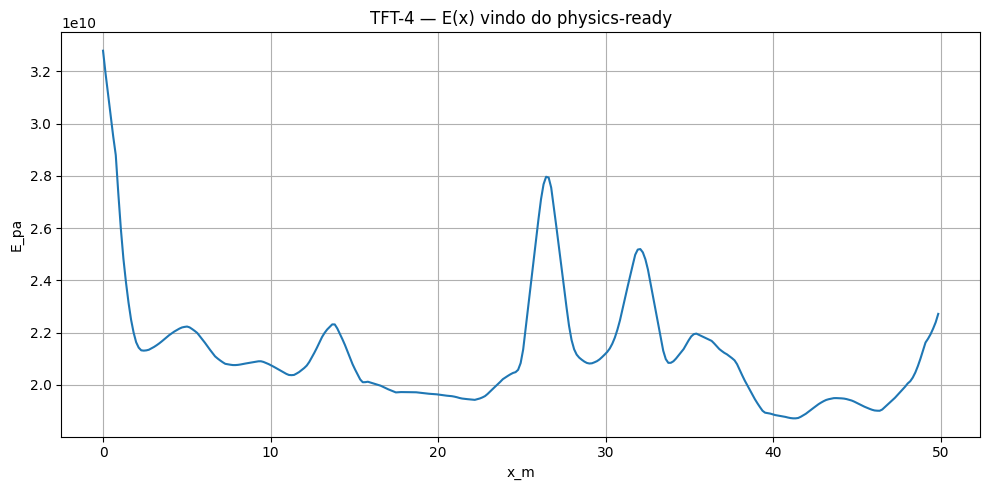

,DEPTH,x_m,E_pa
0,"2,350.136400",0.000000,"32,786,153,018.229519"
1,"2,350.288400",0.152000,"31,905,485,503.589760"
2,"2,350.440400",0.304000,"31,103,994,897.294281"
3,"2,350.592400",0.456000,"30,277,976,074.992485"
4,"2,350.744400",0.608000,"29,503,347,628.122078"


In [3]:
required_cols = ["DEPTH", "E_pa"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Campos obrigatórios ausentes: {missing}")

work_df = df.copy()

if "physics_ready_valid" in work_df.columns:
    work_df = work_df[work_df["physics_ready_valid"].fillna(False).astype(bool)].copy()

work_df = work_df.dropna(subset=["DEPTH", "E_pa"]).sort_values("DEPTH").reset_index(drop=True)

if len(work_df) < 5:
    raise ValueError("Poucos pontos válidos para FEniCSx.")

work_df["x_m"] = work_df["DEPTH"] - work_df["DEPTH"].min()

L = float(work_df["x_m"].max())
N_data = len(work_df)

print(f"Pontos válidos: {N_data:,}")
print(f"Comprimento da zona L = {L:,.6f} m")

plt.figure(figsize=(10, 5))
plt.plot(work_df["x_m"], work_df["E_pa"], "-")
plt.title(f"{WELL_NAME} — E(x) vindo do physics-ready")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.grid(True)
plt.tight_layout()
plt.show()

display(work_df[["DEPTH", "x_m", "E_pa"]].head())

## Interpretação

Criamos a coordenada local:

```text
x = DEPTH - DEPTH_MIN
```

Agora a zona do poço virou um domínio 1D:

```text
0 <= x <= L
```

E o módulo de Young virou uma função física do domínio:

```text
E(x)
```

# STEP 3 — Create 1D Mesh

In [4]:
N_CELLS = max(10, N_data - 1)

domain = mesh.create_interval(
    MPI.COMM_WORLD,
    N_CELLS,
    [0.0, L],
)

print(f"Número de células: {N_CELLS}")
print(f"Dimensão da malha: {domain.topology.dim}")
print(f"Comprimento L: {L:,.6f} m")

Número de células: 328
Dimensão da malha: 1
Comprimento L: 49.856000 m


## Interpretação

A malha divide a zona física em pequenos elementos.

O FEM resolve a física nesses elementos.

Essa é a primeira vez que o reservatório vira uma malha computacional real dentro do FEniCSx.

# STEP 4 — Create Function Space

In [5]:
V = fem.functionspace(domain, ("Lagrange", 1))

print("Function space criado.")
print("Número global de graus de liberdade:", V.dofmap.index_map.size_global)

Function space criado.
Número global de graus de liberdade: 329


## Interpretação

O espaço funcional define como o FEniCSx representa a solução `u(x)`.

Usamos:

```text
Lagrange P1
```

Ou seja, deslocamento linear dentro de cada elemento.

# STEP 5 — Interpolate E(x) into FEniCSx

In [6]:
x_data = work_df["x_m"].to_numpy(dtype=float)
E_data = work_df["E_pa"].to_numpy(dtype=float)

E_fem = fem.Function(V)
E_fem.name = "E_pa"

def E_interpolator(x):
    return np.interp(x[0], x_data, E_data)

E_fem.interpolate(E_interpolator)

dof_coords = V.tabulate_dof_coordinates().reshape((-1, domain.geometry.dim))[:, 0]
E_values = E_fem.x.array.real.copy()

e_plot_df = pd.DataFrame({
    "x_m": dof_coords,
    "E_fem": E_values,
}).sort_values("x_m")

plt.figure(figsize=(10, 5))
plt.plot(x_data, E_data, ".", alpha=0.45, label="E do Parquet")
plt.plot(e_plot_df["x_m"], e_plot_df["E_fem"], "-", label="E no FEniCSx")
plt.title(f"{WELL_NAME} — E(x) interpolado na malha FEM")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display(e_plot_df.head())
display(e_plot_df.tail())

ValueError: All arrays must be of the same length

## Interpretação

Este é um passo gigante.

Antes:

```text
E_pa era uma coluna do pandas
```

Agora:

```text
E_pa virou uma função FEM: E(x)
```

Isso significa que o dado petrofísico virou coeficiente físico da PDE.

# STEP 6 — Boundary Condition

In [ ]:
def base_boundary(x):
    return np.isclose(x[0], L)

base_dofs = fem.locate_dofs_geometrical(V, base_boundary)

u_base = fem.Constant(domain, PETSc.ScalarType(0.0))
bc_base = fem.dirichletbc(u_base, base_dofs, V)

print("DOFs fixados na base:", base_dofs)

## Interpretação

Fixamos a base da zona:

```text
u(L) = 0
```

Isso dá uma referência mecânica para o problema.

O topo e o interior respondem à carga aplicada.

# STEP 7 — Weak Form

In [ ]:
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

dx = ufl.dx(domain)
f = fem.Constant(domain, BODY_FORCE)

# Forma fraca 1D:
# ∫ E(x) du/dx dv/dx dx = ∫ f v dx
a = E_fem * ufl.grad(u)[0] * ufl.grad(v)[0] * dx
L_form = f * v * dx

display(Markdown(f'''
## Forma fraca montada

A forma bilinear representa:

```text
∫ E(x) du/dx dv/dx dx
```

A forma linear representa:

```text
∫ f v dx
```

Carga distribuída usada:

```text
f = {float(BODY_FORCE):,.3e}
```

O FEniCSx agora vai montar internamente o sistema:

```text
K u = F
```
'''))

# STEP 8 — Solve FEM Problem

In [ ]:
problem = LinearProblem(
    a,
    L_form,
    bcs=[bc_base],
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
)

uh = problem.solve()
uh.name = "displacement_u"

u_values = uh.x.array.real.copy()

solution_df = pd.DataFrame({
    "x_m": dof_coords,
    "u_m": u_values,
    "E_pa": E_values,
}).sort_values("x_m").reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.plot(solution_df["u_m"], solution_df["x_m"], "-")
plt.gca().invert_yaxis()
plt.title(f"{WELL_NAME} — Deslocamento FEM u(x)")
plt.xlabel("u_m")
plt.ylabel("x_m")
plt.grid(True)
plt.tight_layout()
plt.show()

display(solution_df.head())
display(solution_df.tail())

## Interpretação

Agora temos uma solução FEM real.

`u(x)` é o deslocamento calculado pelo FEniCSx.

Diferente do notebook 05A, aqui não integramos manualmente.

O FEniCSx resolveu uma PDE via elementos finitos.

# STEP 9 — Compute Strain and Stress

In [ ]:
solution_df["epsilon"] = np.gradient(solution_df["u_m"], solution_df["x_m"])
solution_df["sigma_pa"] = solution_df["E_pa"] * solution_df["epsilon"]

fig, axes = plt.subplots(1, 4, figsize=(18, 8), sharey=True)

axes[0].plot(solution_df["E_pa"], solution_df["x_m"], "-")
axes[0].set_title("E_pa")
axes[0].set_xlabel("E_pa")

axes[1].plot(solution_df["u_m"], solution_df["x_m"], "-")
axes[1].set_title("u_m")
axes[1].set_xlabel("u_m")

axes[2].plot(solution_df["epsilon"], solution_df["x_m"], "-")
axes[2].set_title("epsilon")
axes[2].set_xlabel("epsilon")

axes[3].plot(solution_df["sigma_pa"], solution_df["x_m"], "-")
axes[3].set_title("sigma_pa")
axes[3].set_xlabel("sigma_pa")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
fig.suptitle(f"{WELL_NAME} — FEniCSx 1D Elasticity Results", y=1.02)
plt.tight_layout()
plt.show()

display(solution_df.describe().T)

## Interpretação

Agora temos:

```text
u(x)       = deslocamento
epsilon   = deformação
sigma     = tensão
```

A deformação foi calculada como:

```text
epsilon = du/dx
```

A tensão foi calculada como:

```text
sigma = E * epsilon
```

Este é o primeiro resultado mecânico completo usando FEM real.

# STEP 10 — Convert Back to Real Depth

In [ ]:
depth_min = float(work_df["DEPTH"].min())

solution_df["DEPTH"] = solution_df["x_m"] + depth_min
solution_df["WELL"] = WELL_NAME

fig, axes = plt.subplots(1, 3, figsize=(15, 9), sharey=True)

axes[0].plot(solution_df["u_m"], solution_df["DEPTH"], "-")
axes[0].set_title("u_m")
axes[0].set_xlabel("u_m")

axes[1].plot(solution_df["epsilon"], solution_df["DEPTH"], "-")
axes[1].set_title("epsilon")
axes[1].set_xlabel("epsilon")

axes[2].plot(solution_df["sigma_pa"], solution_df["DEPTH"], "-")
axes[2].set_title("sigma_pa")
axes[2].set_xlabel("sigma_pa")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("DEPTH")
fig.suptitle(f"{WELL_NAME} — Resultado FEM em profundidade real", y=1.02)
plt.tight_layout()
plt.show()

display(solution_df.head())
display(solution_df.tail())

## Interpretação

Agora a resposta FEM voltou para o eixo de profundidade real do poço.

Isso permite comparar os resultados com:

- VSH;
- AI;
- facies;
- zonas;
- anomalias;
- módulos elásticos.

# STEP 11 — Sanity Check: E versus Strain

In [ ]:
corr_e_eps = solution_df[["E_pa", "epsilon"]].corr(method="spearman").iloc[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(solution_df["E_pa"], solution_df["epsilon"], s=20, alpha=0.7)
plt.title(f"{WELL_NAME} — E_pa x epsilon — Spearman={corr_e_eps:.3f}")
plt.xlabel("E_pa")
plt.ylabel("epsilon")
plt.grid(True)
plt.tight_layout()
plt.show()

display(Markdown(f'''
## Interpretação

Correlação Spearman entre `E_pa` e `epsilon`:

```text
{corr_e_eps:.4f}
```

O módulo de Young controla a deformação, mas neste problema FEM a resposta também depende da posição e da condição de contorno.

Este gráfico é uma checagem de sanidade física.
'''))

# STEP 12 — Export Results

In [ ]:
safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

simulation_path = DATA_SIMULATION_DIR / f"{safe_well_name}_fenicsx_elasticity_1d.parquet"
solution_df.to_parquet(simulation_path, index=False)

summary_df = pd.DataFrame([{
    "WELL": WELL_NAME,
    "SOURCE_PHYSICS_READY_PARQUET": str(selected_physics_path),
    "SIMULATION_PARQUET": str(simulation_path),
    "N_CELLS": N_CELLS,
    "N_DOF": len(solution_df),
    "L_M": L,
    "BODY_FORCE": float(BODY_FORCE),
    "U_MIN": solution_df["u_m"].min(),
    "U_MAX": solution_df["u_m"].max(),
    "EPSILON_MIN": solution_df["epsilon"].min(),
    "EPSILON_MAX": solution_df["epsilon"].max(),
    "SIGMA_MIN_PA": solution_df["sigma_pa"].min(),
    "SIGMA_MAX_PA": solution_df["sigma_pa"].max(),
}])

summary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_elasticity_1d_summary.csv"
summary_df.to_csv(summary_path, index=False)

column_dictionary = pd.DataFrame({
    "COLUMN": solution_df.columns,
    "DTYPE": [str(solution_df[c].dtype) for c in solution_df.columns],
    "NON_NULL_COUNT": [solution_df[c].notna().sum() for c in solution_df.columns],
    "NULL_COUNT": [solution_df[c].isna().sum() for c in solution_df.columns],
    "FILL_RATE": [solution_df[c].notna().mean() for c in solution_df.columns],
})

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_elasticity_1d_column_dictionary.csv"
column_dictionary.to_csv(column_dictionary_path, index=False)

print("SIMULAÇÃO FENICSX EXPORTADA COM SUCESSO!")
print(f"Parquet: {simulation_path}")
print(f"Resumo: {summary_path}")
print(f"Dicionário: {column_dictionary_path}")

display(summary_df)
display(column_dictionary)

# STEP 13 — Final Interpretation

Este notebook fez a primeira simulação real com FEniCSx.

## Caminho realizado

```text
physics-ready parquet
↓
malha 1D
↓
FunctionSpace
↓
E(x) como função FEM
↓
forma fraca
↓
condição de contorno
↓
solver PETSc
↓
u(x), epsilon(x), sigma(x)
```

## Por que isso é importante?

Porque agora você sabe transformar:

```text
logs petrofísicos
```

em:

```text
coeficientes de uma PDE resolvida por FEM
```

## Próximo passo natural

Agora sim podemos construir:

```text
05B — Single Well 1D Poroelasticity with FEniCSx
```

Com:

```text
u(x,t) + p(x,t)
```

Ou seja:

```text
deformação + pressão de poro
```